Mounted at /content/drive


/tmp/ipykernel_2431/1878244809.py:48: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  all_cols  = merged.columns


loaded: 57936 rows, 3432 columns
After PRCDDA filter and leakage removal: 56857 rows, 3429 features
Removed 0 zero-variance columns
Missing values before imputation: 0
Missing values after imputation: 0
Remaining features: 3429
Train: 45485 rows, Test: 11372 rows


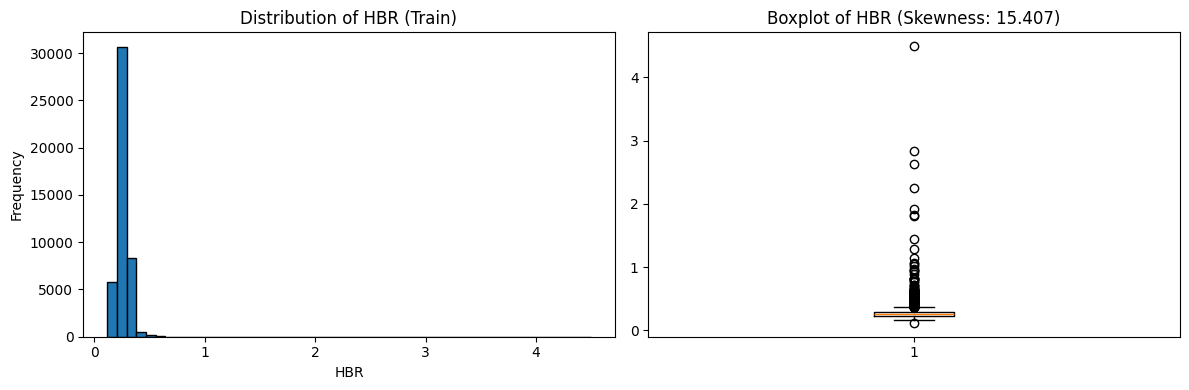

Skewness of y: 15.407


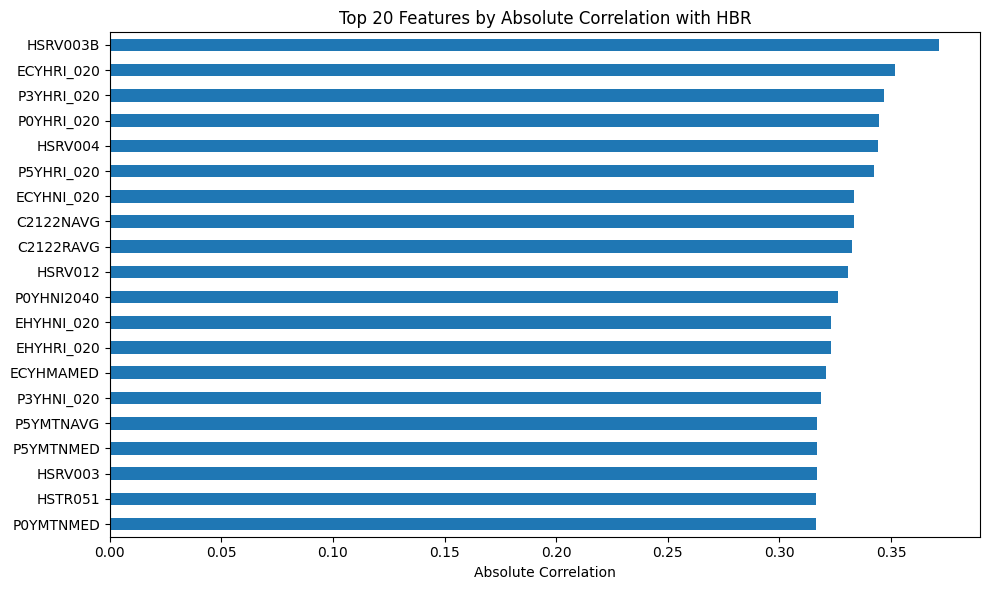

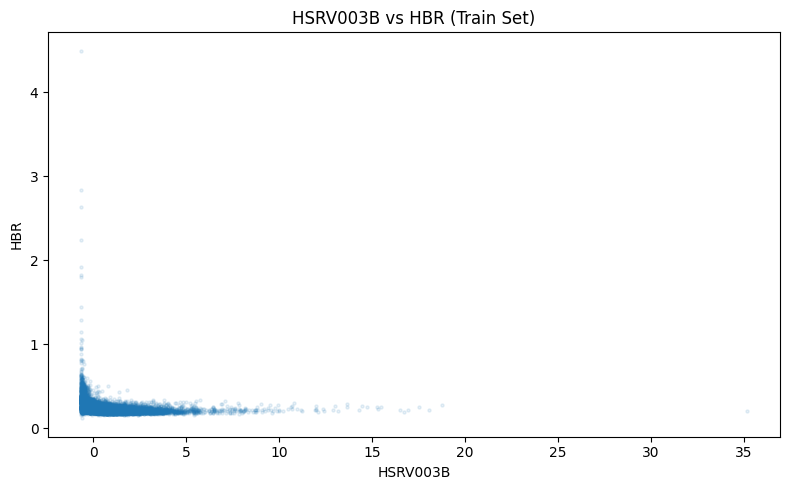

k=2: Inertia=121756031, Silhouette=0.7472
k=3: Inertia=106026517, Silhouette=0.5128
k=4: Inertia=99514562, Silhouette=0.3399
k=5: Inertia=95662381, Silhouette=0.2466
k=6: Inertia=93163106, Silhouette=0.1264
k=7: Inertia=91274888, Silhouette=0.1145
k=8: Inertia=89631511, Silhouette=0.0711
k=9: Inertia=87964308, Silhouette=0.1017
k=10: Inertia=86697120, Silhouette=0.0242
k=11: Inertia=85294806, Silhouette=0.0348
k=12: Inertia=84145319, Silhouette=0.0392


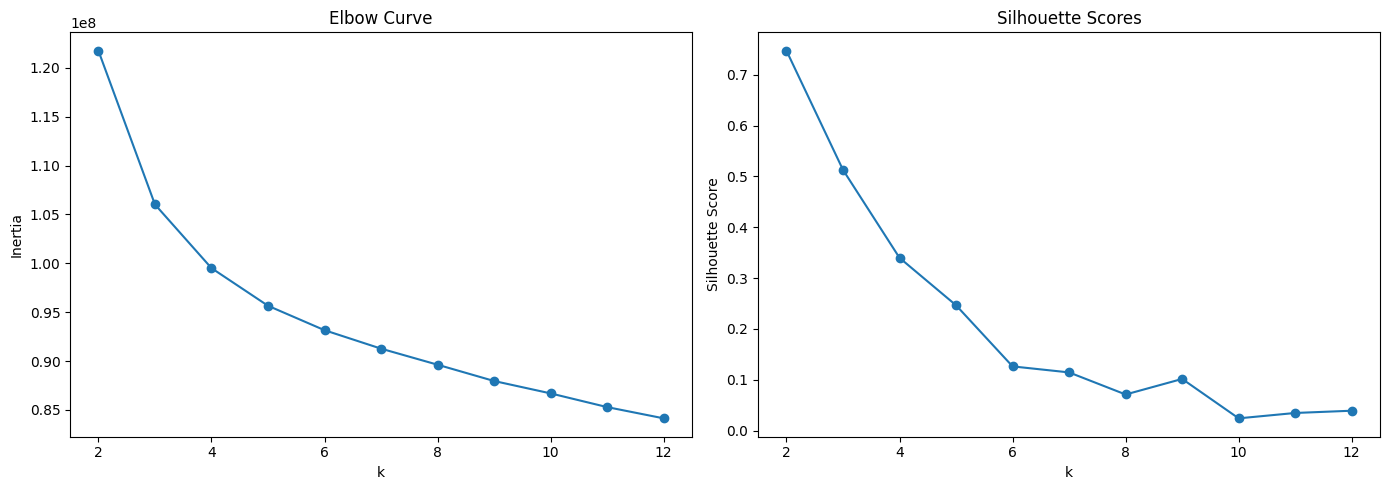

Best k by silhouette score: 2


In [ ]:
#!pip install polars

import pandas as pd
import numpy as np
import zipfile
import os
import gc
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

# unzip files
with zipfile.ZipFile("/content/drive/MyDrive/Data/HouseholdSpend_CSV.zip", "r") as z:
    z.extractall("/content/household_data")

with zipfile.ZipFile("/content/drive/MyDrive/Data/DemoStats_CSV.zip", "r") as z:
    z.extractall("/content/demostats_data")

# filter to PRCDDA in polars lazy mode - entire merge before touching pandas
lf1 = pl.scan_csv("/content/household_data/HouseholdSpend_(HHS)_2025_GEO_P1.csv", infer_schema_length=10000)
lf2 = pl.scan_csv("/content/household_data/HouseholdSpend_(HHS)_2025_GEO_P2.csv", infer_schema_length=10000)
hhs = (lf1.filter(pl.col("GEO") == "PRCDDA")
          .join(lf2.filter(pl.col("GEO") == "PRCDDA"), on=["CODE", "GEO"], how="inner"))

demo_files = [
    os.path.join(root, f)
    for root, dirs, files in os.walk("/content/demostats_data")
    for f in files if f.endswith(".csv") and "Documentation" not in root
]

demo = pl.scan_csv(demo_files[0], infer_schema_length=10000).filter(pl.col("GEO") == "PRCDDA")
for f in demo_files[1:]:
    demo = demo.join(
        pl.scan_csv(f, infer_schema_length=10000).filter(pl.col("GEO") == "PRCDDA"),
        on=["CODE", "GEO"], how="inner"
    )

# build HBR and drop leakage columns while still lazy (before any RAM is used)
merged = hhs.join(demo, on=["CODE", "GEO"], how="inner")
all_cols  = merged.columns
leak_cols = [c for c in all_cols if c.startswith("HSSH")] + \
            ["HSAGDISPIN", "HSAGDISCIN", "HSHNIAGG", "HSTT001", "HSTE001", "HSTX001", "HSTC001"]
leak_cols = [c for c in leak_cols if c in all_cols]

merged = merged.with_columns(
    (pl.col("HSSH001S") / pl.col("HSAGDISPIN")).alias("HBR")
).drop(leak_cols)

# collect into pandas in one shot
df = merged.collect().to_pandas()
del merged, hhs, demo, lf1, lf2
gc.collect()

df.reset_index(drop=True, inplace=True)
print(f"loaded: {df.shape[0]} rows, {df.shape[1]} columns")

y = df["HBR"]
X = df.drop(columns=["CODE", "GEO", "HBR"])
X = X.select_dtypes(include=[np.number])

valid = np.isfinite(y)
X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)

del df
gc.collect()

print(f"After PRCDDA filter and leakage removal: {X.shape[0]} rows, {X.shape[1]} features")

# remove zero-variance columns and handle missing values
zero_var_cols = X.columns[X.var() == 0]
X = X.drop(columns=zero_var_cols)
print(f"Removed {len(zero_var_cols)} zero-variance columns")

# Justification: Zero-variance columns carry no discriminative information
# and are removed as they cannot contribute to any model.

print(f"Missing values before imputation: {X.isnull().sum().sum()}")
X = X.fillna(X.median())
print(f"Missing values after imputation: {X.isnull().sum().sum()}")

# Justification: Median imputation is chosen over mean because household
# expenditure variables tend to be right-skewed, making the median more
# robust to outliers and a better representation of the typical value.

# report remaining features and standardise
print(f"Remaining features: {X.shape[1]}")

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
del X
gc.collect()

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
del X_scaled
gc.collect()
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")

# Justification: An 80/20 split is chosen as it provides sufficient training
# data (~45k rows) while reserving a large enough test set (~11k rows) for
# reliable evaluation. random_state=42 ensures reproducibility.

# distribution of target variable y
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=50, edgecolor="black")
axes[0].set_title("Distribution of HBR (Train)")
axes[0].set_xlabel("HBR")
axes[0].set_ylabel("Frequency")

skewness = skew(y_train)
axes[1].boxplot(y_train, vert=True)
axes[1].set_title(f"Boxplot of HBR (Skewness: {skewness:.3f})")
plt.tight_layout()
plt.show()
print(f"Skewness of y: {skewness:.3f}")

# top predictors correlated with y
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
top_20 = correlations.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_20.plot(kind="barh", ax=ax)
ax.set_title("Top 20 Features by Absolute Correlation with HBR")
ax.set_xlabel("Absolute Correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_feature = top_20.index[0]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train[top_feature], y_train, alpha=0.1, s=5)
ax.set_xlabel(top_feature)
ax.set_ylabel("HBR")
ax.set_title(f"{top_feature} vs HBR (Train Set)")
plt.tight_layout()
plt.show()

# K-Means Clustering

# i. run KMeans for k = 2,...,12
k_range = range(2, 13)
inertias = []
sil_scores = []

# silhouette on a 5000-row sample
sample_idx = np.random.RandomState(42).choice(X_train.shape[0], size=5000, replace=False)
X_sample = X_train.iloc[sample_idx]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_full = km.fit_predict(X_train)
    inertias.append(km.inertia_)
    labels_sample = labels_full[sample_idx]
    sil_scores.append(silhouette_score(X_sample, labels_sample))
    print(f"k={k}: Inertia={km.inertia_:.0f}, Silhouette={sil_scores[-1]:.4f}")

# plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker="o")
axes[0].set_title("Elbow Curve")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[1].plot(k_range, sil_scores, marker="o")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

# select optimal k
best_k_sil = list(k_range)[np.argmax(sil_scores)]
print(f"Best k by silhouette score: {best_k_sil}")


Reported Cluster Sizes: labels
0    44540
1      945
Name: count, dtype: int64


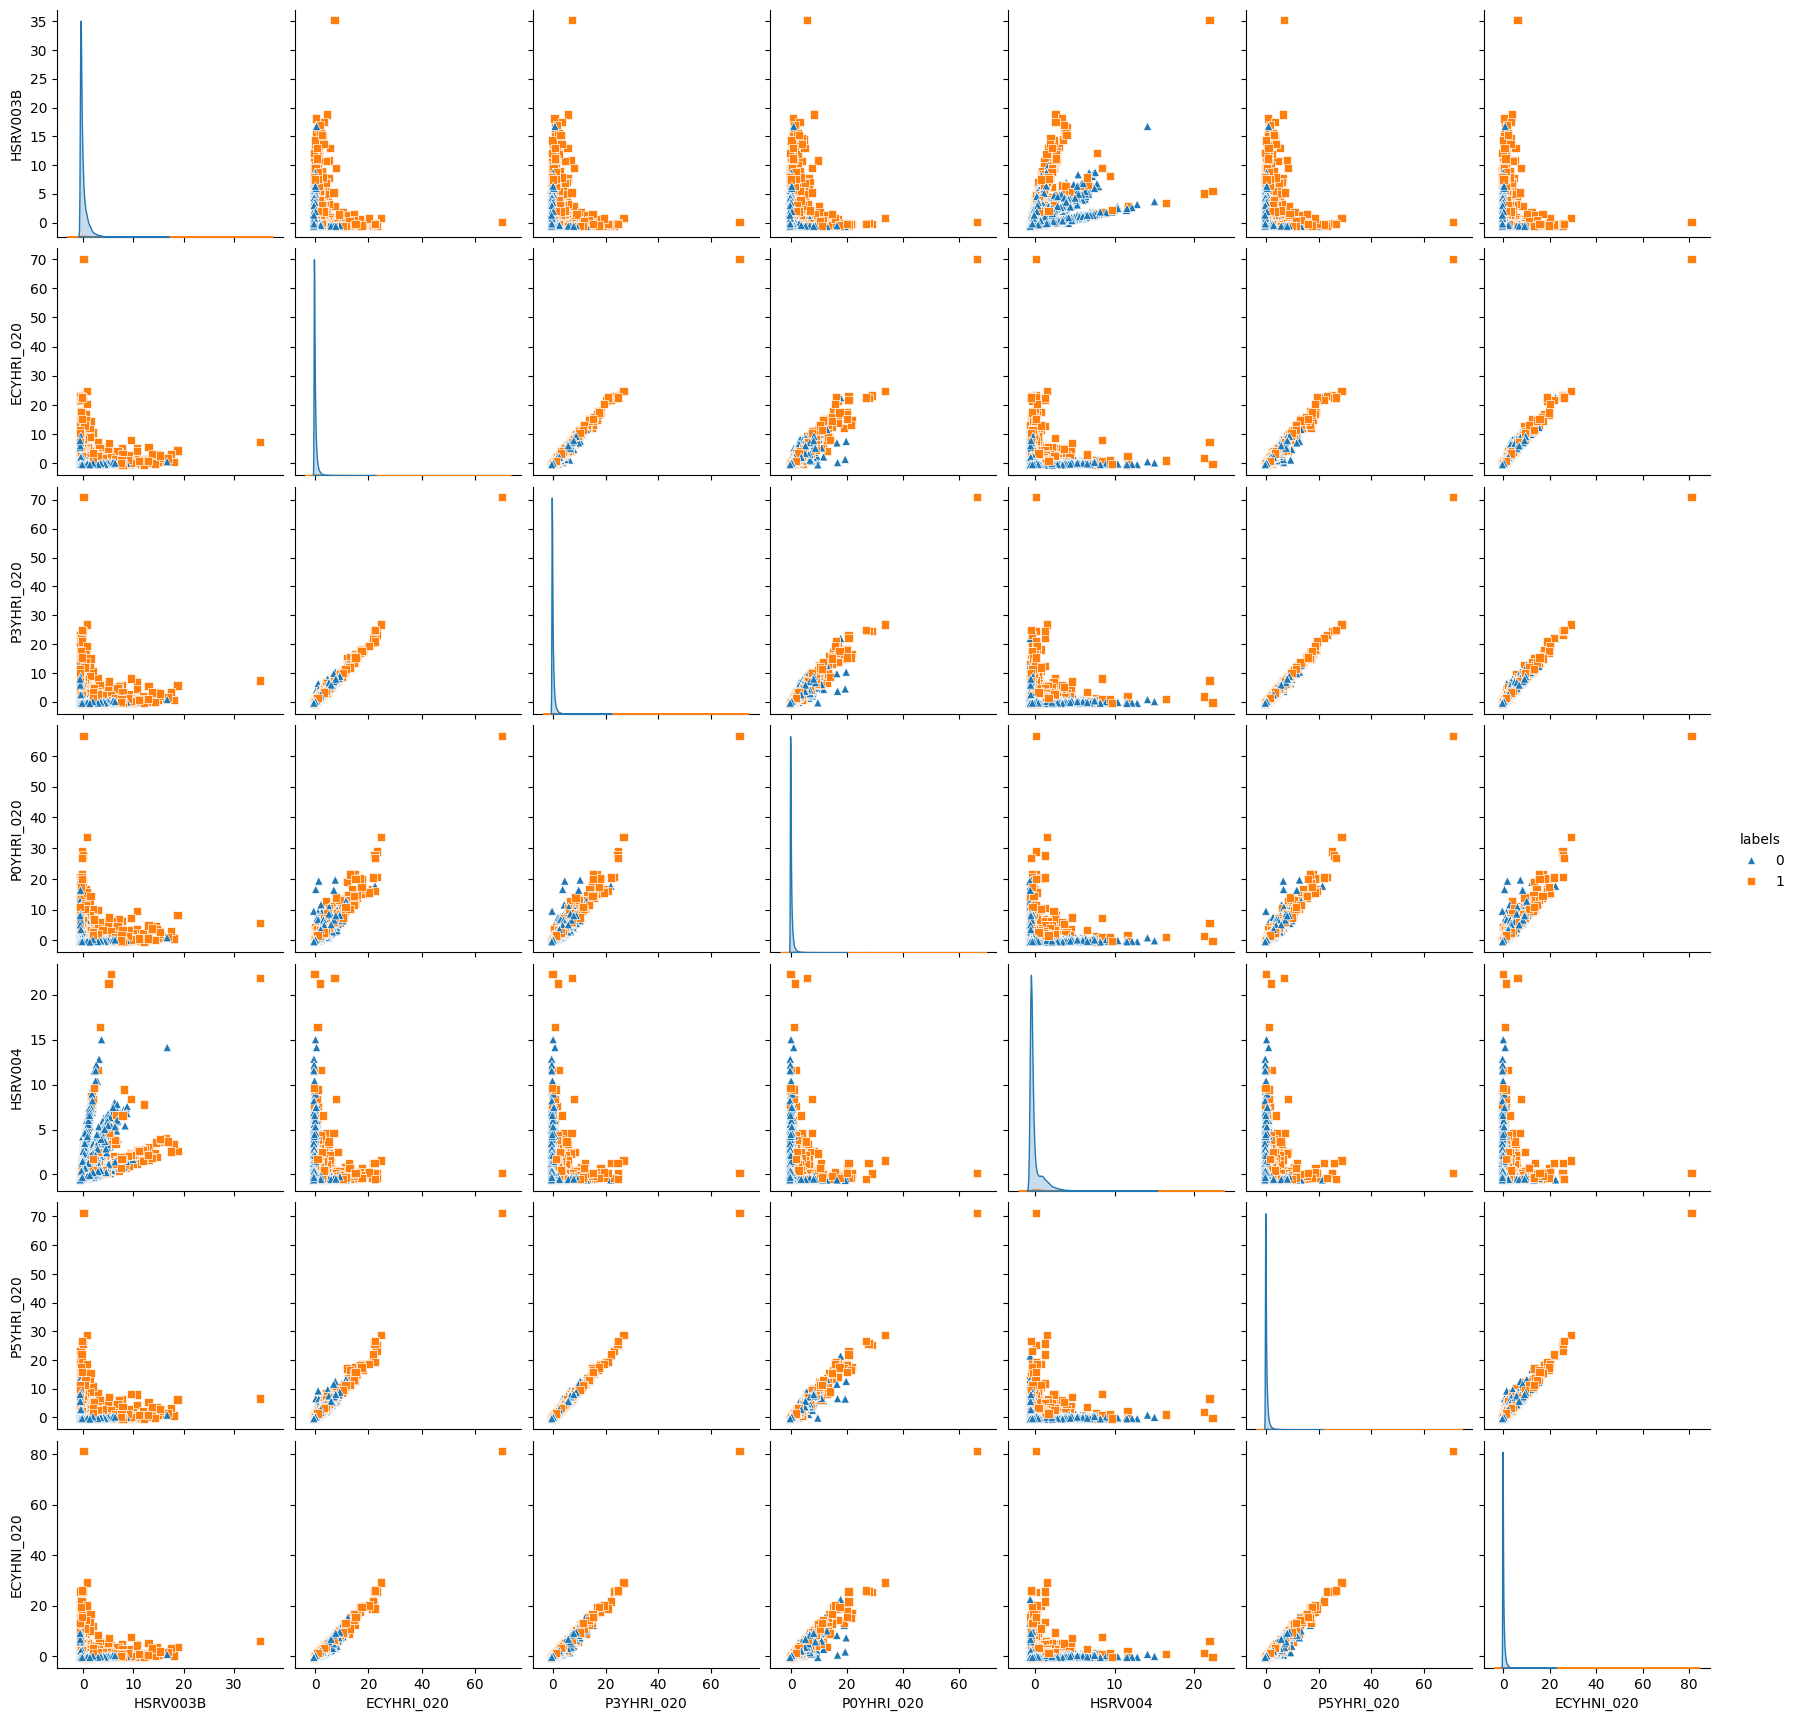

Compared feature means on interpretable variables:         HSRV003B  ECYHRI_020  P3YHRI_020  P0YHRI_020   HSRV004  P5YHRI_020  \
labels                                                                       
0      -0.042918   -0.049371   -0.050795   -0.052063 -0.016465   -0.051308   
1       1.945161    2.294242    2.370186    2.477945  0.786468    2.404879   

        ECYHNI_020  
labels              
0        -0.049271  
1         2.299558  


In [ ]:
# report cluster sizes and compare feature means

X_train_clean = X_train.copy()  # keep a clean copy for PCA/UMAP later

KClusterer = KMeans(n_clusters=best_k_sil, random_state=42)
labels = KClusterer.fit_predict(X_train)
X_train["labels"] = labels

print("Reported Cluster Sizes:", X_train["labels"].value_counts().sort_index())

variables = {}
variables["feature_names"] = ["HSRV003B", "ECYHRI_020", "P3YHRI_020", "P0YHRI_020", "HSRV004", "P5YHRI_020", "ECYHNI_020"]

sns.pairplot(vars=variables["feature_names"], hue='labels', markers=["^", "s"], data=X_train)
plt.show()

print("Compared feature means on interpretable variables:", X_train.groupby("labels")[variables["feature_names"]].mean())

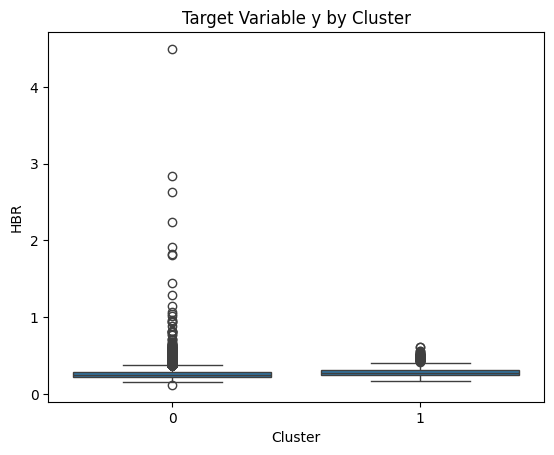

In [ ]:
# create a boxplot of the target variable y by cluster

X_train["HBR"] = y_train.values
sns.boxplot(x="labels", y="HBR", data=X_train)
plt.xlabel("Cluster")
plt.ylabel("HBR")
plt.title("Target Variable y by Cluster")
plt.show()

**PCA**

Cumulative variance explained by top 10 PCs: 0.656067116462495


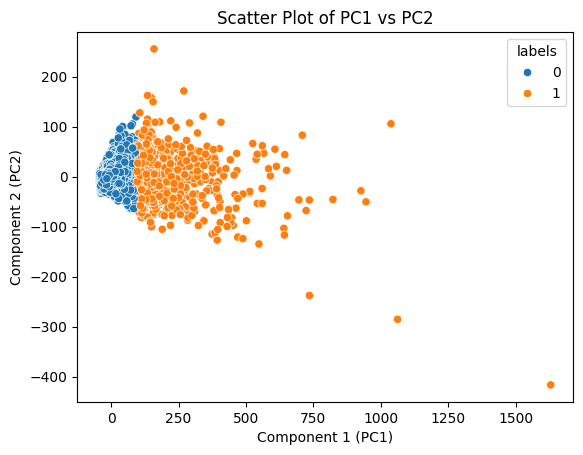

In [ ]:
from sklearn.decomposition import PCA

# perform PCA, report cumulative variance of top 10 components
nPCA = PCA(n_components=10)
nPCA.fit(np.asarray(X_train_clean))
print("Cumulative variance explained by top 10 PCs:", nPCA.explained_variance_ratio_.sum())

# scatter plot of PC1 vs PC2 coloured by KMeans labels
Z1 = nPCA.transform(np.asarray(X_train_clean))
sns.scatterplot(x=Z1[:, 0], y=Z1[:, 1], hue=X_train["labels"])
plt.xlabel("Component 1 (PC1)")
plt.ylabel("Component 2 (PC2)")
plt.title("Scatter Plot of PC1 vs PC2")
plt.show()

In [ ]:
# for the top 3 PCs, list top-loading features
for i in range(3):
    indices = np.argpartition(np.abs(nPCA.components_[i, :]), -5)[-5:]
    print(f"PC{i+1}", X_train_clean.columns[indices], nPCA.components_[i, indices])

PC1 Index(['P3YCWHPL', 'P3YMARHP15', 'P3YBAS15HP', 'P3YEDUHP15', 'P3YBAS12HP'], dtype='object') [0.02556774 0.02556774 0.02556774 0.02556774 0.0255798 ]
PC2 Index(['P5YHTAMED', 'ECYPTAMED', 'P3YPTAMED', 'P3YHTAMED', 'ECYHTAMED'], dtype='object') [0.04829505 0.0483882  0.04849532 0.04878498 0.04910706]
PC3 Index(['ECYHRIMED', 'EHYHNI2040', 'EHYHRI2040', 'EHYHRIMED', 'EHYHNIMED'], dtype='object') [ 0.05787506 -0.05925884 -0.05925884  0.05961563  0.05961563]


In [ ]:
# compute mean PC scores by cluster (PC1-PC3)
PC_df = pd.DataFrame(Z1[:, :3], columns=["PC1", "PC2", "PC3"])
PC_df["labels"] = X_train["labels"]
print(PC_df.groupby("labels").mean())

             PC1       PC2       PC3
labels                              
0.0     0.123309  0.001369 -0.002640
1.0     0.587440 -0.546444 -0.620363


**UMAP**

In [ ]:
#!pip install umap-learn
import umap

# search for optimal n_neighbors
X_train_umap = X_train.drop(columns=["labels", "HBR"], errors="ignore").copy()

# test a range of n_neighbors values to find the one that best preserves
# cluster structure in 2D - measured by silhouette score
neighbors_range = [15, 30, 50]
umap_sil_scores = []

for n in neighbors_range:
    reducer_test = umap.UMAP(
        n_components=2,        # reduce to 2D
        n_neighbors=n,         # number of neighbours to consider
        n_epochs=200,          # default iterations, sufficient for convergence
        low_memory=True,       # required given RAM constraints
        random_state=42,
        n_jobs=1               # sequential to avoid RAM spike
    )
    emb = reducer_test.fit_transform(X_train_umap)
    score = silhouette_score(emb, X_train["labels"])
    umap_sil_scores.append(score)
    print(f"n_neighbors={n}: silhouette={score:.4f}")
    del reducer_test, emb    # free RAM before next iteration
    gc.collect()

best_n = neighbors_range[np.argmax(umap_sil_scores)]
print(f"best n_neighbors: {best_n}")

# fit final UMAP with the optimal n_neighbors
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=best_n,
    min_dist=0.3,              # controls how tightly points cluster together
    metric='euclidean',
    n_epochs=200,
    low_memory=True,
    random_state=42,
    n_jobs=1,
    verbose=True
)
UMAP_embedding = reducer.fit_transform(X_train_umap)
del X_train_umap
gc.collect()
print("UMAP embedding shape:", UMAP_embedding.shape)

# Justification: n_neighbors controls how UMAP balances local vs global
# structure. Small values focus on local detail, large values capture
# broader patterns. We pick the value that gives the best silhouette
# score, meaning clusters are most clearly separated in 2D.

n_neighbors=15: silhouette=0.2279
n_neighbors=30: silhouette=0.2342
n_neighbors=50: silhouette=0.2400
best n_neighbors: 50
UMAP(min_dist=0.3, n_epochs=200, n_jobs=1, n_neighbors=50, random_state=42, verbose=True)
Fri Apr 17 18:29:43 2026 Construct fuzzy simplicial set
Fri Apr 17 18:29:43 2026 Finding Nearest Neighbors
Fri Apr 17 18:29:43 2026 Building RP forest with 16 trees
Fri Apr 17 18:29:57 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Fri Apr 17 18:31:49 2026 Finished Nearest Neighbor Search
Fri Apr 17 18:31:50 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Fri Apr 17 18:32:37 2026 Finished embedding
UMAP embedding shape: (45485, 2)


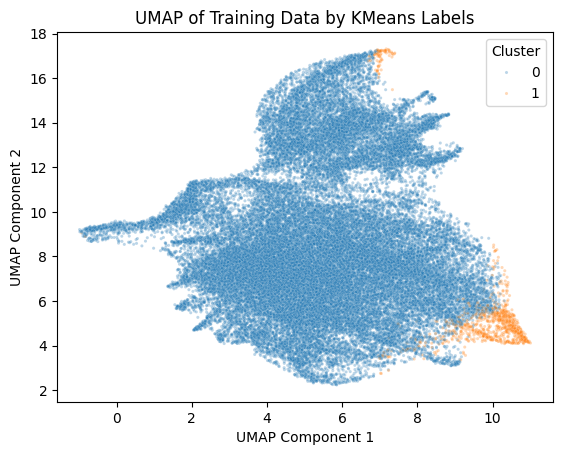

In [ ]:
# scatter plot of UMAP dimensions coloured by KMeans labels
sns.scatterplot(x=UMAP_embedding[:, 0], y=UMAP_embedding[:, 1],
                hue=X_train["labels"], palette="tab10", alpha=0.3, s=5)
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("UMAP of Training Data by KMeans Labels")
plt.legend(title="Cluster")
plt.show()

# UMAP is a non-linear method so it can capture structure that PCA misses.
# If clusters are more clearly separated here than in the PCA scatter plot,
# UMAP is a better 2D representation. If they still overlap a lot, it
# suggests the clusters are not very distinct even with non-linear methods.

In [ ]:
# silhouette score in 2D UMAP space vs high-dimensional space
umap_sil = silhouette_score(UMAP_embedding, X_train["labels"])
print(f"Silhouette in 2D UMAP space:          {umap_sil:.4f}")
print(f"Silhouette in high-dimensional space: {sil_scores[best_k_sil - 2]:.4f}")

# If the UMAP silhouette is higher, it means UMAP found a 2D layout
# where clusters look more distinct than in the original space. This
# suggests the data has non-linear structure that UMAP captures well.
# If it's lower, some cluster separation is lost when compressing to 2D,
# which is expected since we go from thousands of dimensions to just two.

# The clusters that appear consistently separated across all three
# representations (KMeans, PCA, UMAP) are the most reliable and informative,
# since their structure holds regardless of the method used to visualise them.

Silhouette in 2D UMAP space:          0.2624
Silhouette in high-dimensional space: 0.7472


In [ ]:
# clear dimensionality reduction objects from RAM before supervised learning
import joblib

del Z1, nPCA, UMAP_embedding, reducer, PC_df, X_train_clean, X_sample
gc.collect()
print("RAM cleared after section 2")

# save clean checkpoint - drop labels and HBR before saving
X_train_save = X_train.drop(columns=["labels", "HBR"], errors="ignore")
X_test_save  = X_test.drop(columns=["labels", "HBR"], errors="ignore")

joblib.dump(
    (X_train_save, X_test_save, y_train, y_test, best_k_sil),
    "/content/checkpoint.pkl"
)
del X_train_save, X_test_save
gc.collect()
print("checkpoint saved")

RAM cleared after section 2
checkpoint saved


**Elastic-Net GLM**

checkpoint loaded - features: 3429
y_train_z mean: -0.0035  std: 0.9839
features after selection: 500
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.734e+03, tolerance: 4.403e+01
  model = cd_fast.enet_coordinate_descent(


best alpha: 0.0001  l1_ratio: 0.9
saved
test R²: 0.4365  |  test MSE: 0.002190
bootstrap 95% CI: [0.2204, 0.7072]


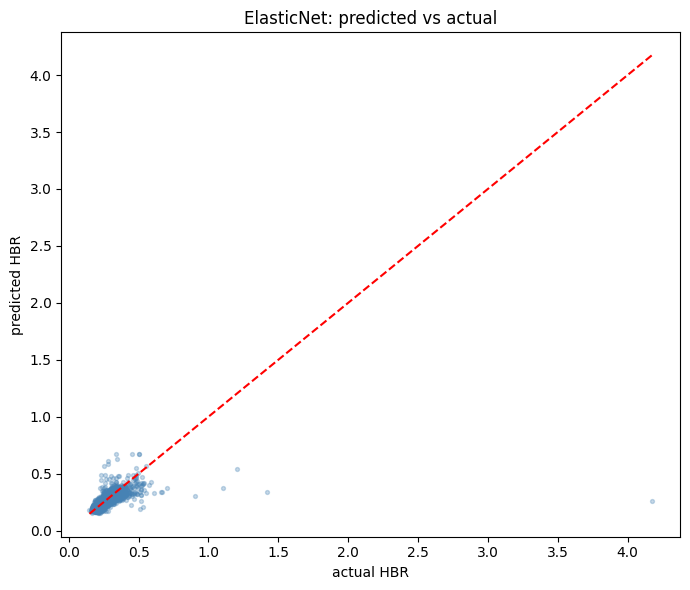


R² per cluster:
  cluster 0: R² = 0.4374  95% CI [0.2493, 0.7330]
  cluster 1: R² = -0.0462  95% CI [-0.6499, 0.3627]

non-zero coefficients: 374 / 500
   feature      coef
   HSRV022  0.941804
Y23NINCAVG  0.802428
Y23RINCAVG  0.778121
   HSRV021 -0.665439
   HSRV081 -0.548573


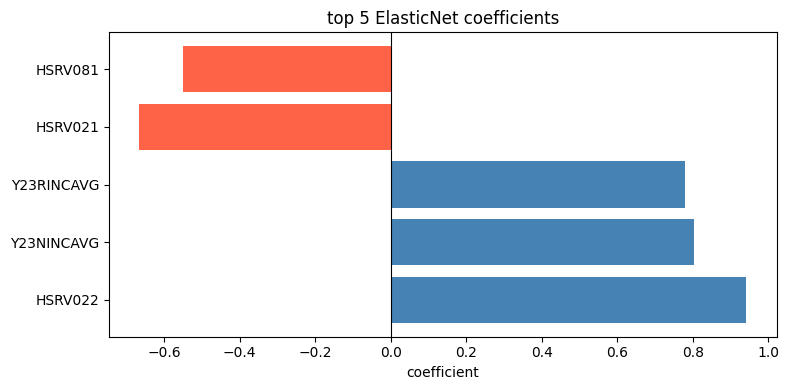

7061

In [ ]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

!pip install distfit -q

from distfit import distfit
from scipy.stats import pearson3, norm
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# reload checkpoint
X_tr, X_te, y_train, y_test, best_k_sil = joblib.load("/content/checkpoint.pkl")
gc.collect()
print(f"checkpoint loaded - features: {X_tr.shape[1]}")

# fit PT3 to y_train, map y -> PT3 CDF -> normal z-scores
dfit = distfit(todf=True, verbose=0)
dfit.fit_transform(y_train.values)

params = pearson3.fit(y_train.values)

def to_z(y_vals, params):
    cdf = np.clip(pearson3.cdf(y_vals, *params), 1e-6, 1 - 1e-6)
    return norm.ppf(cdf)

def from_z(z_vals, params):
    cdf = np.clip(norm.cdf(z_vals), 1e-6, 1 - 1e-6)
    return pearson3.ppf(cdf, *params)

y_train_z = to_z(y_train.values, params)
y_test_z  = to_z(y_test.values, params)
print(f"y_train_z mean: {y_train_z.mean():.4f}  std: {y_train_z.std():.4f}")

# select top 500 features by correlation with y_train_z on train set only (no leakage) - due to computational restraints
top_feats = pd.Series(
    np.abs(np.corrcoef(X_tr.T, y_train_z)[-1, :-1]),
    index=X_tr.columns
).nlargest(500).index
X_tr = X_tr[top_feats]
X_te = X_te[top_feats]
print(f"features after selection: {X_tr.shape[1]}")

# already standardised in section 1

# grid search - l1_ratio avoids 0 and 1 extremes which are slow to converge
param_grid = {
    "alpha":    [1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
}

gs = GridSearchCV(
    ElasticNet(max_iter=5000, tol=1e-3, selection="random", random_state=42),
    param_grid, cv=5, scoring="r2",
    n_jobs=-1,
    verbose=1
)
gs.fit(X_tr, y_train_z)
print(f"best alpha: {gs.best_params_['alpha']}  l1_ratio: {gs.best_params_['l1_ratio']}")

joblib.dump(gs, "/content/gs_elasticnet.pkl")
print("saved")

# reverse transform back to original HBR space
y_pred_enet = from_z(gs.best_estimator_.predict(X_te), params)

# performance + bootstrapped 95% CI
test_r2  = r2_score(y_test, y_pred_enet)
test_mse = mean_squared_error(y_test, y_pred_enet)
print(f"test R²: {test_r2:.4f}  |  test MSE: {test_mse:.6f}")

rng = np.random.default_rng(42)
n   = len(y_test)
boot_r2 = []
for _ in range(1000):
    idx = rng.integers(0, n, size=n)
    boot_r2.append(r2_score(y_test.values[idx], y_pred_enet[idx]))
ci_low, ci_high = np.percentile(boot_r2, [2.5, 97.5])
print(f"bootstrap 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_enet, alpha=0.3, s=8, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=1.5)
plt.xlabel("actual HBR")
plt.ylabel("predicted HBR")
plt.title("ElasticNet: predicted vs actual")
plt.tight_layout()
plt.show()

# R² per cluster
km_final = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
km_final.fit(X_tr)
kmeans_labels_test = km_final.predict(X_te)

rng2 = np.random.default_rng(42)
print("\nR² per cluster:")
for cl in np.unique(kmeans_labels_test):
    mask   = kmeans_labels_test == cl
    cl_r2  = r2_score(y_test.values[mask], y_pred_enet[mask])
    idx_cl = np.where(mask)[0]
    boot_cl = []
    for _ in range(1000):
        s = rng2.choice(idx_cl, len(idx_cl), replace=True)
        boot_cl.append(r2_score(y_test.values[s], y_pred_enet[s]))
    lo, hi = np.percentile(boot_cl, [2.5, 97.5])
    print(f"  cluster {cl}: R² = {cl_r2:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

# non-zero coefficients and top 5 by magnitude
coef    = gs.best_estimator_.coef_
coef_df = pd.DataFrame({"feature": X_tr.columns, "coef": coef})
coef_df = coef_df[coef_df["coef"] != 0].assign(abs_coef=lambda d: d["coef"].abs())
print(f"\nnon-zero coefficients: {len(coef_df)} / {len(coef)}")

top5 = coef_df.nlargest(5, "abs_coef")
print(top5[["feature", "coef"]].to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(top5["feature"], top5["coef"],
         color=["tomato" if c < 0 else "steelblue" for c in top5["coef"]])
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("coefficient")
plt.title("top 5 ElasticNet coefficients")
plt.tight_layout()
plt.show()

del gs, coef, coef_df
gc.collect()

**XGBoost**

Fitting 5 folds for each of 20 candidates, totalling 100 fits
best params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
XGBoost saved
test R²: 0.7411  |  test MSE: 0.001006
bootstrap 95% CI: [0.6201, 0.9240]


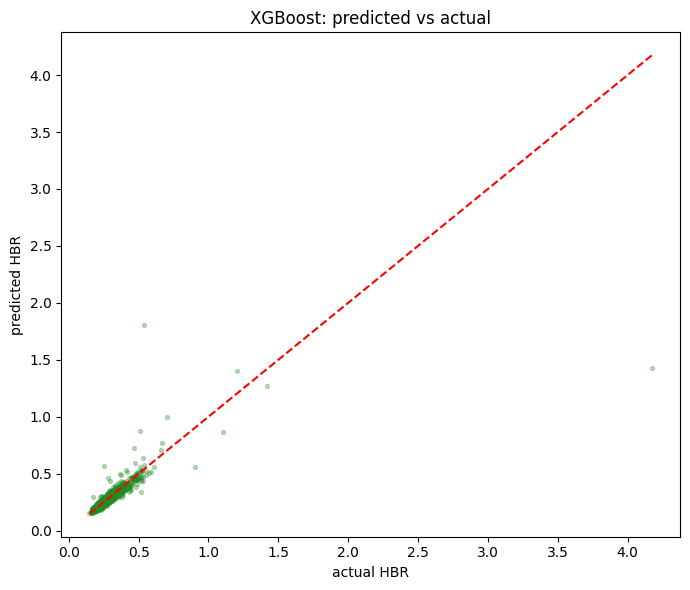

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

# reload full feature set - 3429 features, no reduction needed for XGBoost
X_tr, X_te, y_train, y_test, best_k_sil = joblib.load("/content/checkpoint.pkl")
gc.collect()
print(f"XGBoost using full feature set: {X_tr.shape[1]} features")

# use y directly - no PT3 transform needed for XGBoost
# X_tr and X_te already in memory from 3a

# RandomizedSearchCV - param grid choices:
# n_estimators: more trees = better fit but slower, test range 100-500
# max_depth: deeper = more complex and risk of overfit, keep 3-6
# learning_rate: lower = more robust but needs more trees, test 0.01-0.2
# subsample: row sampling reduces overfitting, test 0.6-1.0
# colsample_bytree: column sampling per tree, test 0.6-1.0
# tree_method=hist: significantly faster on large datasets
param_dist = {
    "n_estimators":     [100, 200, 300, 500],
    "max_depth":        [3, 4, 5, 6],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}
# RandomizedSearchCV with 20 iterations = 20 combos x 5 folds = 100 fits
# much faster than GridSearchCV on this many hyperparameters

rs = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, tree_method="hist"),
    param_dist, n_iter=20, cv=5, scoring="r2",
    random_state=42, n_jobs=1, verbose=1
)
rs.fit(X_tr, y_train)
print(f"best params: {rs.best_params_}")

# save immediately
joblib.dump(rs, "/content/rs_xgboost.pkl")
print("XGBoost saved")

y_pred_xgb = rs.best_estimator_.predict(X_te)

# performance + bootstrapped 95% CI
test_r2_xgb  = r2_score(y_test, y_pred_xgb)
test_mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f"test R\u00b2: {test_r2_xgb:.4f}  |  test MSE: {test_mse_xgb:.6f}")

rng3 = np.random.default_rng(42)
boot_r2_xgb = []
for _ in range(1000):
    idx = rng3.integers(0, n, size=n)
    boot_r2_xgb.append(r2_score(y_test.values[idx], y_pred_xgb[idx]))
ci_low_xgb, ci_high_xgb = np.percentile(boot_r2_xgb, [2.5, 97.5])
print(f"bootstrap 95% CI: [{ci_low_xgb:.4f}, {ci_high_xgb:.4f}]")

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, s=8, color="forestgreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=1.5)
plt.xlabel("actual HBR")
plt.ylabel("predicted HBR")
plt.title("XGBoost: predicted vs actual")
plt.tight_layout()
plt.show()

**SHAP**

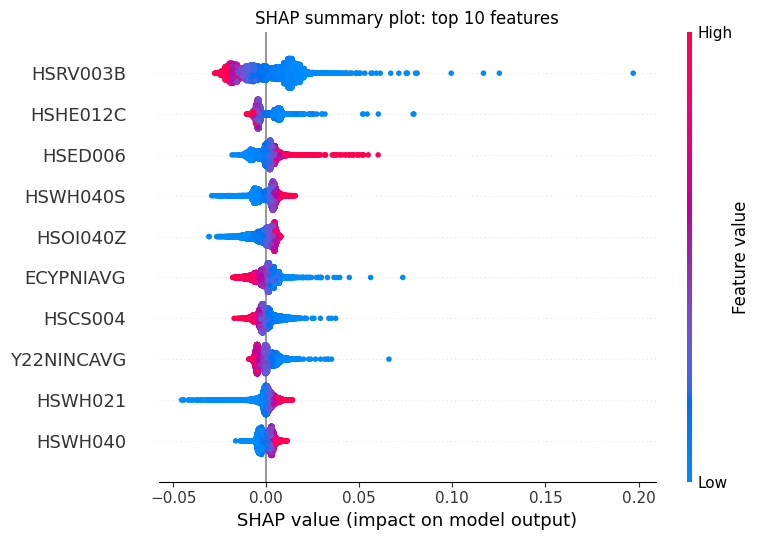

top 10 features by mean absolute SHAP:
   1. HSRV003B: 0.011897
   2. HSHE012C: 0.005212
   3. HSED006: 0.004293
   4. HSWH040S: 0.004291
   5. HSOI040Z: 0.004195
   6. ECYPNIAVG: 0.003945
   7. HSCS004: 0.003703
   8. Y22NINCAVG: 0.003581
   9. HSWH021: 0.002882
  10. HSWH040: 0.002871


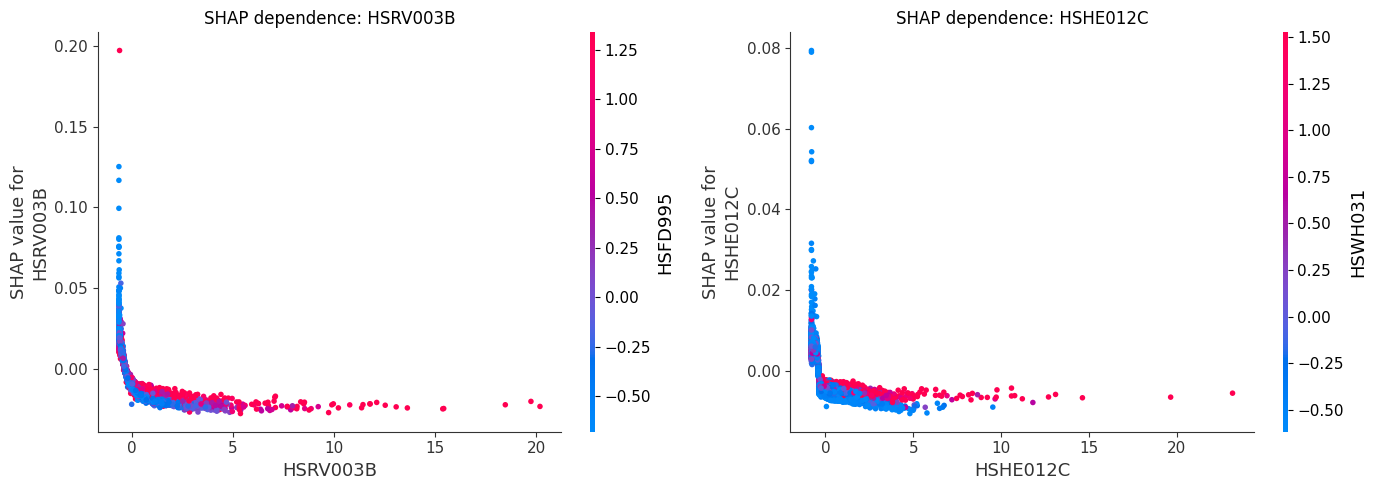


top SHAP features vs ElasticNet coefficients:
  top 5 SHAP:       ['HSRV003B', 'HSHE012C', 'HSED006', 'HSWH040S', 'HSOI040Z']
  top 5 ElasticNet: ['HSRV022', 'Y23NINCAVG', 'Y23RINCAVG', 'HSRV021', 'HSRV081']


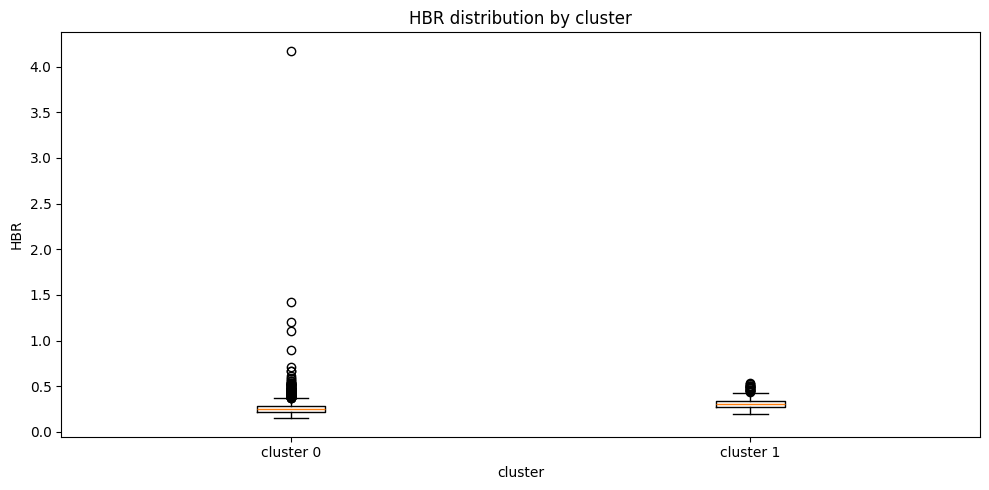

In [ ]:
!pip install shap -q
import shap

# compute SHAP values using TreeExplainer on test set
explainer   = shap.TreeExplainer(rs.best_estimator_)
shap_values = explainer.shap_values(X_te)

# beeswarm summary plot - top 10 features by mean absolute SHAP
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_te, max_display=10, show=False)
plt.title("SHAP summary plot: top 10 features")
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top10_idx     = np.argsort(mean_abs_shap)[::-1][:10]
top10_feats   = X_tr.columns[top10_idx]
print("top 10 features by mean absolute SHAP:")
for i, (f, v) in enumerate(zip(top10_feats, mean_abs_shap[top10_idx]), 1):
    print(f"  {i:2d}. {f}: {v:.6f}")

# two dependence plots for top 2 features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i in range(2):
    shap.dependence_plot(top10_feats[i], shap_values, X_te, ax=axes[i], show=False)
    axes[i].set_title(f"SHAP dependence: {top10_feats[i]}")
plt.tight_layout()
plt.show()

# compare top SHAP features vs ElasticNet top 5
print("\ntop SHAP features vs ElasticNet coefficients:")
print(f"  top 5 SHAP:       {list(top10_feats[:5])}")
print(f"  top 5 ElasticNet: {list(top5['feature'])}")

# HBR distribution across clusters
fig, ax = plt.subplots(figsize=(10, 5))
cluster_hbr = [y_test.values[kmeans_labels_test == cl] for cl in np.unique(kmeans_labels_test)]
ax.boxplot(cluster_hbr, labels=[f"cluster {cl}" for cl in np.unique(kmeans_labels_test)])
ax.set_xlabel("cluster")
ax.set_ylabel("HBR")
ax.set_title("HBR distribution by cluster")
plt.tight_layout()
plt.show()